In [ ]:
from pybatteryid.utilities import load_model_from_file, invert_voltage_function
from pybatteryid.plotter import plot_time_vs_current

from pybatteryse.statespace import StateSpace
from pybatteryse.plotter import plot_custom, plot_soc_vs_gramian
from pybatteryse.utilities import compute_soc_observability_contributions, simulate_state_trajectory

from data import helper

### SOC observability analysis

We analyse SOC observability by computing finite-horizon observability Gramians, which quantify the accumulated sensitivity of the voltage output to a unit SOC perturbation over a fixed time horizon.

#### A. Load the test dataset

In [4]:
CHEMISTRY = 'lfp'
# 
dataset = helper.load_npy_datasets(f'data/{CHEMISTRY}_soc_estimation/validation_cold.npy')

In [5]:
time_values = dataset['time_values'] / 3600
current_values = dataset['current_values']
voltage_values = dataset['voltage_values']
temperature_values = dataset['temperature_values']

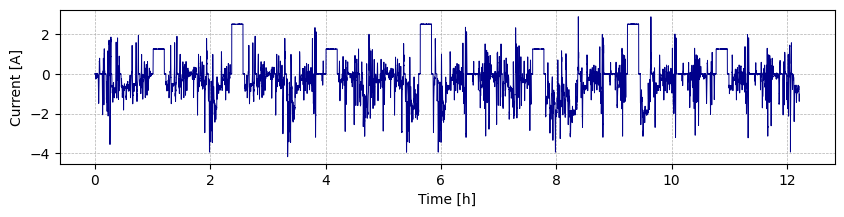

In [6]:
#
plot_time_vs_current([(time_values, current_values)],
                      units=('h', 'A'), colors=['darkblue'],
                      figsize=(10, 2))

#### B. Load models

In [7]:
model_lti = load_model_from_file(f'data/{CHEMISTRY}_soc_estimation/model_lti_n=1.npy')
model_lpv = load_model_from_file(f'data/{CHEMISTRY}_soc_estimation/model_lpv_n,l=3,3.npy')
#

#### C. Load state-space representation

In [8]:
ss_representation_lti = StateSpace(model_lti, state_components=['s', 'overpotentials'])
ss_representation_lpv = StateSpace(model_lpv, state_components=['s', 'overpotentials'])

Here, we first determine true state trajectories for the two models, and then compute Gramians.

In [ ]:
initial_soc = invert_voltage_function(model_lti.emf_function, voltage_values[0])
#
true_states = simulate_state_trajectory(ss_representation_lti,
                                        initial_state=[initial_soc] + [0] * model_lti.model_order,
                                        current_values=dataset['current_values'],
                                        temperature_values=dataset['temperature_values'])
contributions_lti = compute_soc_observability_contributions(ss_representation_lti,
                                                            state_values=true_states,
                                                            current_values=dataset['current_values'],
                                                            temperature_values=dataset['temperature_values'])
#
true_states = simulate_state_trajectory(ss_representation_lpv,
                                        initial_state=[initial_soc] + [0] * model_lpv.model_order,
                                        current_values=dataset['current_values'],
                                        temperature_values=dataset['temperature_values'])
contributions_lpv = compute_soc_observability_contributions(ss_representation_lpv,
                                                            state_values=true_states,
                                                            current_values=dataset['current_values'],
                                                            temperature_values=dataset['temperature_values'])

First, we plot the Gramians as a function of time depending on the provided current profile and the initial state. This allows us to visualise at what time instants the model output voltage is sensitive to the SOC perturbations, that is, when the SOC is observable.

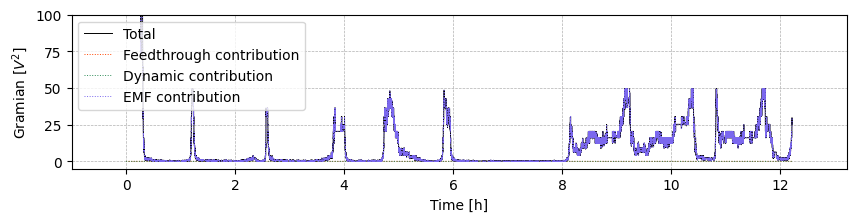

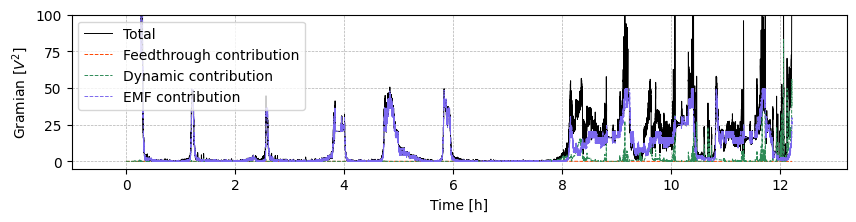

In [11]:
plot_custom(
    [(time_values[:], contributions_lti['total']),
     (time_values[:], contributions_lti['b0_direct']),
     (time_values[:], contributions_lti['op_dynamics']),
     (time_values[:], contributions_lti['emf'])],
    xlabel='Time [h]', ylabel='Gramian [$V^2$]',
    colors=('k', 'orangered', 'seagreen', 'mediumslateblue'),
    linestyles=['-', ':', ':', ':'],
    legends=['Total', 'Feedthrough contribution', 'Dynamic contribution', 'EMF contribution'],
    figsize=(10, 2),
    xlims=(time_values[0]-1, time_values[-1]+1), ylims=(-5, 100)
)

plot_custom(
    [(time_values[:], contributions_lpv['total']),
     (time_values[:], contributions_lpv['b0_direct']),
     (time_values[:], contributions_lpv['op_dynamics']),
     (time_values[:], contributions_lpv['emf'])],
    xlabel='Time [h]', ylabel='Gramian [$V^2$]',
    colors=('k', 'orangered', 'seagreen', 'mediumslateblue'),
    linestyles=['-', '--', '--', '--'],
    legends=['Total', 'Feedthrough contribution', 'Dynamic contribution', 'EMF contribution'],
    figsize=(10, 2),
    xlims=(time_values[0]-1, time_values[-1]+1), ylims=(-5, 100)
)

It may be worth plotting the chart again using total Gramians for the two models as a function of SOC. Note that for the LTI model, the contributions from overpotentials is simply zero.

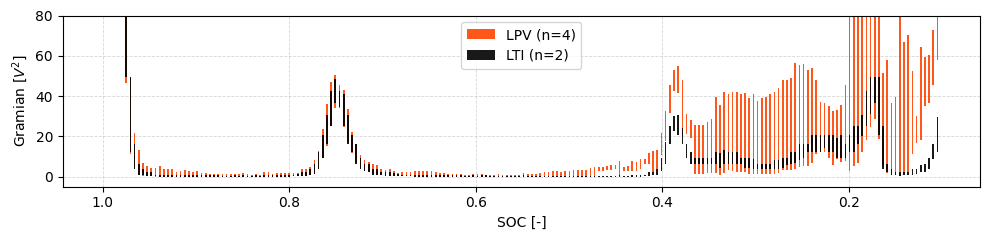

In [12]:
plot_soc_vs_gramian(
    [(true_states[:, 0], contributions_lpv['total']),
     (true_states[:, 0], contributions_lti['total'])],
    colors=('orangered', 'k'),
    legends=[f'LPV (n={ss_representation_lpv.state_dimension})',
             f'LTI (n={ss_representation_lti.state_dimension})'],
    figsize=(10, 2.5),
    ylims=(-5, 80),
    xaxis_reverse=True,
)

We see that sensitivity of voltage output to soc perturbations is higher for LPV models than LTI. Specifically, in the flat regions between $s=0.7$ to $s=0.4$, there is *some* information in the overpotentials in addition to EMF. This is a remarkable result with potentially far reaching consequences.

#### Appendix

In the following, we explain how the observability Gramians are computed. Essentially, we evaluate how a unit perturbation in the SOC state propagates through the linearized dynamics and manifests in the predicted voltage output — quantifying how well SOC is observable from voltage measurements at any given operating point.

In the employed LPV battery models, the terminal voltage decomposes as $V = V_{\text{EMF}}(s) + y$, where the overpotential $y$ is governed by a companion-form state-space with scheduling-dependent coefficients. Taking the derivative of $V$ with respect to the full state vector $\mathbf{x} = [s, \mathbf{x}_{op}^\top, \theta^\top, \ldots]^\top$, the measurement Jacobian $\mathbf{H}$ decomposes exactly via the chain rule into:

$$\mathbf{H} = \mathbf{H}_{\text{EMF}} + \mathbf{H}_{b_0} + \mathbf{H}_{\text{dyn}}$$

where $\mathbf{H}_{\text{EMF}} = [\partial V_{\text{EMF}}/\partial s, 0, \ldots, 0]$, $\mathbf{H}_{b_0} = [\partial b_0(p)/\partial s \cdot u, 0, \ldots, 0]$, and $\mathbf{H}_{\text{dyn}} = [0, 1, 0, \ldots, 0]$ — the companion output readout. For a unit SOC perturbation $\delta\mathbf{x}_0 = \mathbf{e}_s$, the linearized output at step $k$ is $\delta V_k = \mathbf{H}\,\mathbf{A}(p)^k\,\mathbf{e}_s$, where $\mathbf{A}(p)^k\,\mathbf{e}_s$ is the propagated SOC perturbation through the dynamics. The SOC observability Gramian for each component is the accumulated squared output energy
due to that component alone:

$$\mathcal{W}_{(\cdot)} = \sum_{k=0}^{N} \left[ \mathbf{H}_{(\cdot)}\, \mathbf{A}(p)^k\,\mathbf{e}_s \right]^2$$

Since the decomposition of $\mathbf{H}$ is additive and exact, squaring and summing the total output perturbation expands as:

$$\mathcal{W}_{\text{total}} = \mathcal{W}_{\text{EMF}} + \mathcal{W}_{b_0} +
\mathcal{W}_{\text{dyn}} + 2\sum_{k=0}^{N} \left[\mathbf{H}_{\text{EMF}}\,\mathbf{A}^k\mathbf{e}_s\right]
\left[\mathbf{H}_{b_0}\,\mathbf{A}^k\mathbf{e}_s\right] + 2\sum_{k=0}^{N}
\left[\mathbf{H}_{\text{EMF}}\,\mathbf{A}^k\mathbf{e}_s\right]
\left[\mathbf{H}_{\text{dyn}}\,\mathbf{A}^k\mathbf{e}_s\right] + 2\sum_{k=0}^{N}
\left[\mathbf{H}_{b_0}\,\mathbf{A}^k\mathbf{e}_s\right]
\left[\mathbf{H}_{\text{dyn}}\,\mathbf{A}^k\mathbf{e}_s\right]$$

Note that the EMF--$b_0$ cross term is nonzero from $k=0$ since both act on the SOC index, while cross terms involving $\mathbf{H}_{\text{dyn}}$ emerge only from $k=1$ onwards as $\mathbf{A}(p)^k$ mixes SOC into the overpotential states. Consequently, $\mathcal{W}_{\text{EMF}} + \mathcal{W}_{b_0} + \mathcal{W}_{\text{dyn}} \neq \mathcal{W}_{\text{total}}$ and cross terms are tracked separately.